In [46]:
import pandas as pd 
import numpy as np
import os 
import shap
import pickle
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import AdaBoostRegressor,ExtraTreesRegressor,GradientBoostingRegressor, RandomForestRegressor
from sklearn.tree import DecisionTreeRegressor
from catboost import CatBoostRegressor
from xgboost import XGBRegressor
from sklearn.metrics import  mean_squared_error,mean_absolute_error,r2_score , root_mean_squared_error
import warnings

warnings.filterwarnings("ignore")

## Dataset Load

In [2]:
df = pd.read_csv('uber.csv')

## See First 5 Rows of this Dataset

In [3]:
df.head()

,Unnamed: 0,key,fare_amount,pickup_datetime,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,passenger_count
0,24238194,2015-05-07 19:52:06.0000003,7.5,2015-05-07 19:52:06 UTC,-73.999817,40.738354,-73.999512,40.723217,1
1,27835199,2009-07-17 20:04:56.0000002,7.7,2009-07-17 20:04:56 UTC,-73.994355,40.728225,-73.994710,40.750325,1
2,44984355,2009-08-24 21:45:00.00000061,12.9,2009-08-24 21:45:00 UTC,-74.005043,40.740770,-73.962565,40.772647,1
3,25894730,2009-06-26 08:22:21.0000001,5.3,2009-06-26 08:22:21 UTC,-73.976124,40.790844,-73.965316,40.803349,3
4,17610152,2014-08-28 17:47:00.000000188,16.0,2014-08-28 17:47:00 UTC,-73.925023,40.744085,-73.973082,40.761247,5


## See Last 5 Rows of this Dataset

In [4]:
df.tail()

,Unnamed: 0,key,fare_amount,pickup_datetime,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,passenger_count
199995,42598914,2012-10-28 10:49:00.00000053,3.0,2012-10-28 10:49:00 UTC,-73.987042,40.739367,-73.986525,40.740297,1
199996,16382965,2014-03-14 01:09:00.0000008,7.5,2014-03-14 01:09:00 UTC,-73.984722,40.736837,-74.006672,40.739620,1
199997,27804658,2009-06-29 00:42:00.00000078,30.9,2009-06-29 00:42:00 UTC,-73.986017,40.756487,-73.858957,40.692588,2
199998,20259894,2015-05-20 14:56:25.0000004,14.5,2015-05-20 14:56:25 UTC,-73.997124,40.725452,-73.983215,40.695415,1
199999,11951496,2010-05-15 04:08:00.00000076,14.1,2010-05-15 04:08:00 UTC,-73.984395,40.720077,-73.985508,40.768793,1


## Dataset Shape

In [5]:
df.shape

(200000, 9)

# Dataset columns

In [6]:
df.columns

Index(['Unnamed: 0', 'key', 'fare_amount', 'pickup_datetime',
       'pickup_longitude', 'pickup_latitude', 'dropoff_longitude',
       'dropoff_latitude', 'passenger_count'],
      dtype='object')

# Dataset Info

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200000 entries, 0 to 199999
Data columns (total 9 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   Unnamed: 0         200000 non-null  int64  
 1   key                200000 non-null  object 
 2   fare_amount        200000 non-null  float64
 3   pickup_datetime    200000 non-null  object 
 4   pickup_longitude   200000 non-null  float64
 5   pickup_latitude    200000 non-null  float64
 6   dropoff_longitude  199999 non-null  float64
 7   dropoff_latitude   199999 non-null  float64
 8   passenger_count    200000 non-null  int64  
dtypes: float64(5), int64(2), object(2)
memory usage: 13.7+ MB


# Statistical Analysis

In [8]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Unnamed: 0,200000.0,2.771250e+07,1.601382e+07,1.000000,1.382535e+07,2.774550e+07,4.155530e+07,5.542357e+07
fare_amount,200000.0,1.135996e+01,9.901776e+00,-52.000000,6.000000e+00,8.500000e+00,1.250000e+01,4.990000e+02
pickup_longitude,200000.0,-7.252764e+01,1.143779e+01,-1340.648410,-7.399206e+01,-7.398182e+01,-7.396715e+01,5.741846e+01
pickup_latitude,200000.0,3.993589e+01,7.720539e+00,-74.015515,4.073480e+01,4.075259e+01,4.076716e+01,1.644421e+03
dropoff_longitude,199999.0,-7.252529e+01,1.311741e+01,-3356.666300,-7.399141e+01,-7.398009e+01,-7.396366e+01,1.153573e+03
dropoff_latitude,199999.0,3.992389e+01,6.794829e+00,-881.985513,4.073382e+01,4.075304e+01,4.076800e+01,8.726976e+02
passenger_count,200000.0,1.684535e+00,1.385997e+00,0.000000,1.000000e+00,1.000000e+00,2.000000e+00,2.080000e+02


# Handle Missing values

In [9]:
df.isna().sum()

Unnamed: 0           0
key                  0
fare_amount          0
pickup_datetime      0
pickup_longitude     0
pickup_latitude      0
dropoff_longitude    1
dropoff_latitude     1
passenger_count      0
dtype: int64

# Nan value percentage 


In [10]:
df.isnull().mean() * 100

Unnamed: 0           0.0000
key                  0.0000
fare_amount          0.0000
pickup_datetime      0.0000
pickup_longitude     0.0000
pickup_latitude      0.0000
dropoff_longitude    0.0005
dropoff_latitude     0.0005
passenger_count      0.0000
dtype: float64

In [11]:
# First Check the datatype 
df['dropoff_longitude'].dtype # Float 
df['dropoff_latitude'].dtype 


#Handle missng values using standard deviation
df['dropoff_longitude'] = df['dropoff_longitude'].fillna(df['dropoff_longitude'].std())
df['dropoff_latitude'] = df['dropoff_latitude'].fillna(df['dropoff_latitude'].std())

In [12]:
# After handle the nan lets check it again
df.isna().sum()

Unnamed: 0           0
key                  0
fare_amount          0
pickup_datetime      0
pickup_longitude     0
pickup_latitude      0
dropoff_longitude    0
dropoff_latitude     0
passenger_count      0
dtype: int64

# Duplicate value check

In [13]:
df.duplicated().sum()

np.int64(0)

# Feature Engineering

In [14]:
df['pickup_datetime'] = pd.to_datetime(df['pickup_datetime'])

df['hour'] = df['pickup_datetime'].dt.hour
df['day'] = df['pickup_datetime'].dt.day
df['month'] = df['pickup_datetime'].dt.month
df['year'] = df['pickup_datetime'].dt.year
df['dayofweek'] = df['pickup_datetime'].dt.dayofweek

# Fare distribution

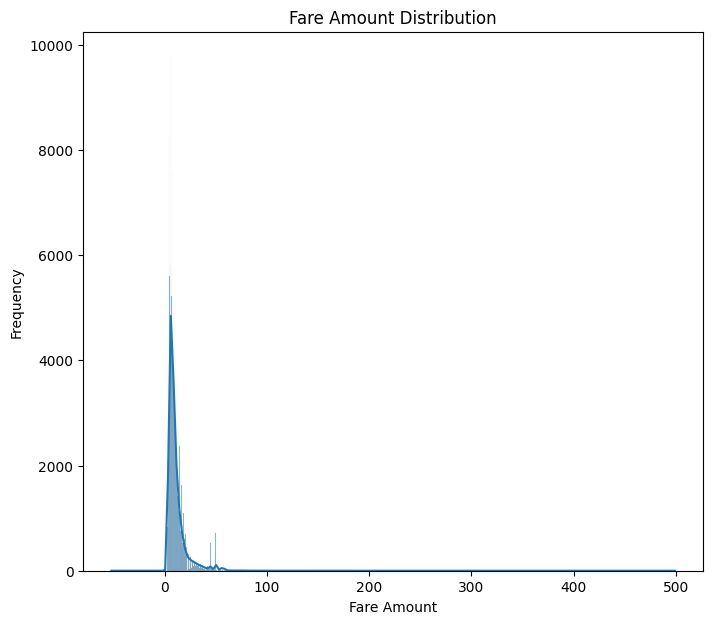

In [15]:
plt.figure(figsize=(8,7))

sns.histplot(df['fare_amount'], kde=True)

plt.title('Fare Amount Distribution')
plt.xlabel('Fare Amount')
plt.ylabel('Frequency')

plt.show()

# Distance vs Fare

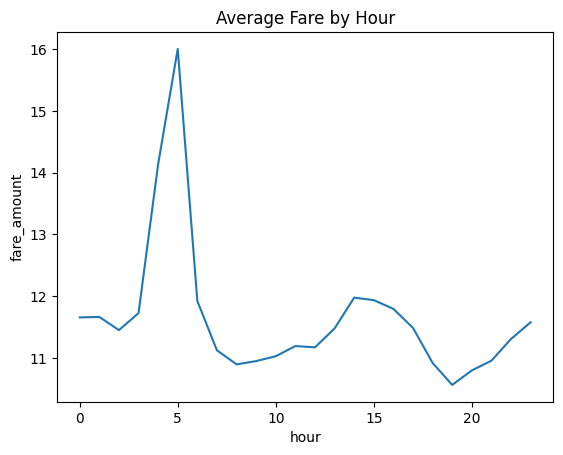

In [16]:
sns.lineplot(data=df.groupby('hour')['fare_amount'].mean().reset_index(),x='hour', y='fare_amount')
plt.title('Average Fare by Hour')
plt.show()

# Avg fare by hour

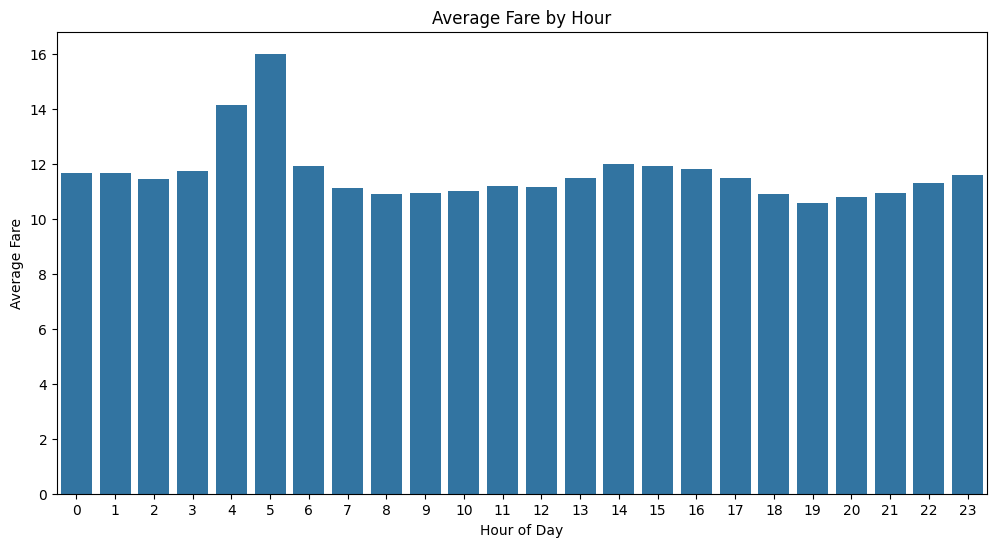

In [17]:
hourly_fare = df.groupby('hour')['fare_amount'].mean().reset_index()

plt.figure(figsize=(12, 6))

sns.barplot(
    data=hourly_fare,
    x='hour',
    y='fare_amount'
)

plt.title('Average Fare by Hour')
plt.xlabel('Hour of Day')
plt.ylabel('Average Fare')

plt.show()

# Day of week vs fare

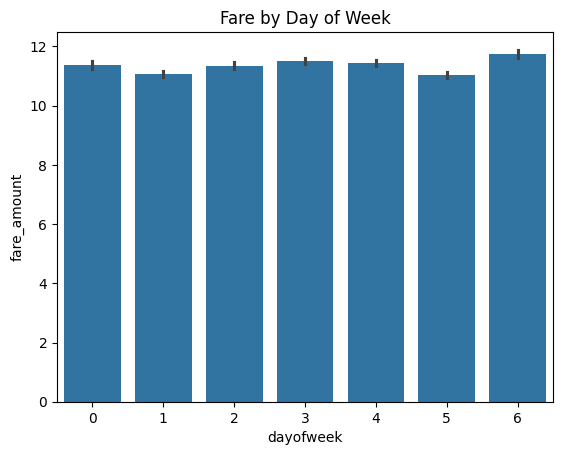

In [18]:
sns.barplot(data=df,x='dayofweek',y='fare_amount')
plt.title('Fare by Day of Week')
plt.show()

# Avg fare by passanger count

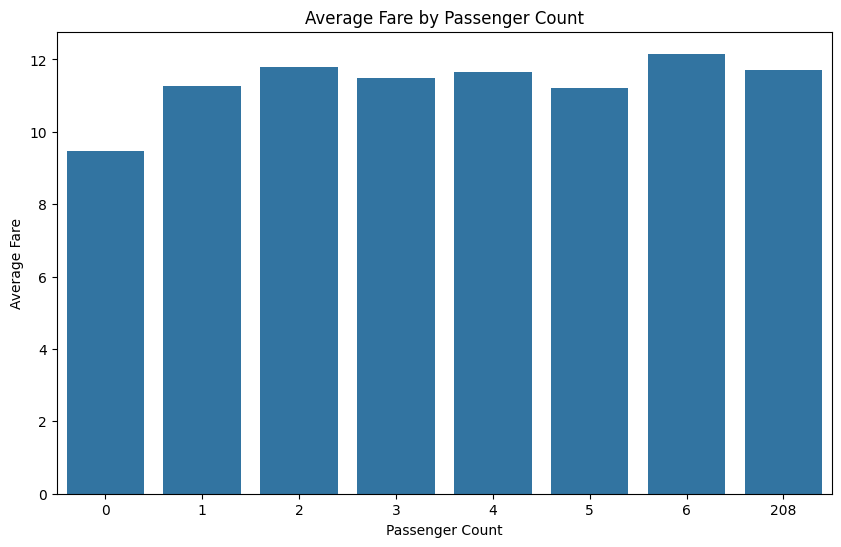

In [19]:
passenger_fare = df.groupby('passenger_count')['fare_amount'].mean().reset_index()

plt.figure(figsize=(10, 6))

sns.barplot(
    data=passenger_fare,
    x='passenger_count',
    y='fare_amount'
)

plt.title('Average Fare by Passenger Count')
plt.xlabel('Passenger Count')
plt.ylabel('Average Fare')

plt.show()

# Data Spliting 

In [20]:
x = df.drop(['fare_amount', 'Unnamed: 0', 'key','pickup_datetime'], axis=1)
y = df['fare_amount']

# Train Test Split Apply

In [21]:
xtrain, xtest, ytrain, ytest = train_test_split(x, y, test_size=0.2, random_state=42)

# Performing Random Forest and Evaluation with Rmse , Mae , Mse and R2 Score

In [22]:
# Random Forest 

rf = RandomForestRegressor(
    n_estimators=100,
    max_depth=10,
    min_samples_split=10,
    min_samples_leaf=5,
    max_features="sqrt",
    random_state=42,
    n_jobs=-1
)

model_rf = rf.fit(xtrain,ytrain)

#Training Score 
print("Training Score For Random Forest : ", model_rf.score(xtrain,ytrain)*100)

#Test Score 
print("Testing Score For Random Forest : ", model_rf.score(xtest,ytest)*100)
print('\n')

# Predictions
ytrain_pred = model_rf.predict(xtrain)
ytest_pred = model_rf.predict(xtest)

# Training Metrics

train_mse_rf = mean_squared_error(ytrain, ytrain_pred)
train_rmse_rf = np.sqrt(train_mse_rf)
train_mae_rf = mean_absolute_error(ytrain, ytrain_pred)
train_r2_rf = r2_score(ytrain, ytrain_pred)

print("Random Forest - Training Metrics")
print("MSE  :", train_mse_rf)
print("RMSE :", train_rmse_rf)
print("MAE  :", train_mae_rf)
print("R2   :", train_r2_rf)

# Testing Metrics

test_mse_rf = mean_squared_error(ytest, ytest_pred)
test_rmse_rf = np.sqrt(test_mse_rf)
test_mae_rf = mean_absolute_error(ytest, ytest_pred)
test_r2_rf = r2_score(ytest, ytest_pred)

print("\nRandom Forest - Testing Metrics")
print("MSE  :", test_mse_rf)
print("RMSE :", test_rmse_rf)
print("MAE  :", test_mae_rf)
print("R2   :", test_r2_rf)

Training Score For Random Forest :  72.73775688332047
Testing Score For Random Forest :  63.8467314319626


Random Forest - Training Metrics
MSE  : 26.165003450007735
RMSE : 5.1151738435763585
MAE  : 3.2905882711649044
R2   : 0.7273775688332047

Random Forest - Testing Metrics
MSE  : 38.43852244254282
RMSE : 6.19988084099548
MAE  : 3.420383555809391
R2   : 0.638467314319626


# Performing Decision Tree and Evaluation with Rmse , Mae , Mse and R2 Score

In [23]:
# Decision Tree
dt = DecisionTreeRegressor(
    max_depth=10,
    min_samples_split=10,
    min_samples_leaf=5,
    random_state=42
)

model_dt = dt.fit(xtrain, ytrain)

print("Training Score For Decision Tree : ", model_dt.score(xtrain,ytrain)*100)
print("Testing Score For Decision Tree : ", model_dt.score(xtest,ytest)*100)
print('\n')
# Predictions
ytrain_pred_dt = model_dt.predict(xtrain)
ytest_pred_dt = model_dt.predict(xtest)


# Training Metrics

train_mse_dt = mean_squared_error(ytrain, ytrain_pred_dt)
train_rmse_dt = np.sqrt(train_mse_dt)
train_mae_dt = mean_absolute_error(ytrain, ytrain_pred_dt)
train_r2_dt = r2_score(ytrain, ytrain_pred_dt   )

print("Decision Tree - Training Metrics")
print("MSE  :", train_mse_dt)
print("RMSE :", train_rmse_dt)
print("MAE  :", train_mae_dt)
print("R2   :", train_r2_dt)
print("R2 % :", train_r2_dt * 100)


# Testing Metrics

test_mse_dt = mean_squared_error(ytest, ytest_pred_dt)
test_rmse_dt = np.sqrt(test_mse_dt)
test_mae_dt = mean_absolute_error(ytest, ytest_pred_dt)
test_r2_dt = r2_score(ytest, ytest_pred_dt   )

print("\nDecision Tree - Testing Metrics")
print("MSE  :", test_mse_dt)
print("RMSE :", test_rmse_dt)
print("MAE  :", test_mae_dt)
print("R2   :", test_r2_dt)
print("R2 % :", test_r2_dt * 100)

Training Score For Decision Tree :  74.78540676541611
Testing Score For Decision Tree :  62.91087879467718


Decision Tree - Training Metrics
MSE  : 24.199766547081687
RMSE : 4.919325822415272
MAE  : 3.122616429597859
R2   : 0.7478540676541611
R2 % : 74.78540676541611

Decision Tree - Testing Metrics
MSE  : 39.43353047434804
RMSE : 6.279612286944795
MAE  : 3.298060133241895
R2   : 0.6291087879467718
R2 % : 62.91087879467718


# Performing Ada Boost and Evaluation with Rmse , Mae , Mse and R2 Score

In [24]:
# AdaBoost

ada = AdaBoostRegressor(
    random_state=42
)

ada_param_grid = {
    'n_estimators': [100, 200],
    'learning_rate': [0.05, 0.1, 0.5]
}

ada_grid = GridSearchCV(
    ada,
    ada_param_grid,
    cv=3,
    scoring='neg_mean_squared_error',
    n_jobs=-1
)

ada_grid.fit(xtrain, ytrain)

print("Best Parameters For AdaBoost : ", ada_grid.best_params_)

model_ada = ada_grid.best_estimator_

print("Training Score For AdaBoost : ", model_ada.score(xtrain, ytrain) * 100)
print("Testing Score For AdaBoost : ", model_ada.score(xtest, ytest) * 100)

print('\n')

ytrain_pred_ada = model_ada.predict(xtrain)
ytest_pred_ada = model_ada.predict(xtest)


# Training Metrics

train_mse_ada = mean_squared_error(ytrain, ytrain_pred_ada)
train_rmse_ada = np.sqrt(train_mse_ada)
train_mae_ada = mean_absolute_error(ytrain, ytrain_pred_ada)
train_r2_ada = r2_score(ytrain, ytrain_pred_ada)

print("AdaBoost - Training Metrics")
print("MSE  :", train_mse_ada)
print("RMSE :", train_rmse_ada)
print("MAE  :", train_mae_ada)
print("R2   :", train_r2_ada)
print("R2 % :", train_r2_ada * 100)


# Testing Metrics

test_mse_ada = mean_squared_error(ytest, ytest_pred_ada)
test_rmse_ada = np.sqrt(test_mse_ada)
test_mae_ada = mean_absolute_error(ytest, ytest_pred_ada)
test_r2_ada = r2_score(ytest, ytest_pred_ada)

print("\nAdaBoost - Testing Metrics")
print("MSE  :", test_mse_ada)
print("RMSE :", test_rmse_ada)
print("MAE  :", test_mae_ada)
print("R2   :", test_r2_ada)
print("R2 % :", test_r2_ada * 100)

Best Parameters For AdaBoost :  {'learning_rate': 0.05, 'n_estimators': 100}
Training Score For AdaBoost :  46.13167281557947
Testing Score For AdaBoost :  41.100803303488476


AdaBoost - Training Metrics
MSE  : 51.70025667345666
RMSE : 7.190289053539966
MAE  : 4.997266678277783
R2   : 0.4613167281557947
R2 % : 46.13167281557947

AdaBoost - Testing Metrics
MSE  : 62.622224317172005
RMSE : 7.9134205194196525
MAE  : 5.079333435944677
R2   : 0.41100803303488476
R2 % : 41.100803303488476


# Performing Cat Boost and Evaluation with Rmse , Mae , Mse and R2 Score

In [25]:
# CatBoost

cat = CatBoostRegressor(
    verbose=0,
    random_seed=42
)

cat_param_grid = {
    'iterations': [200, 400],
    'depth': [6, 8],
    'learning_rate': [0.05, 0.1]
}

cat_grid = GridSearchCV(
    cat,
    cat_param_grid,
    cv=3,
    scoring='neg_mean_squared_error',
    n_jobs=-1
)

cat_grid.fit(xtrain, ytrain)

print("Best Parameters For CatBoost : ", cat_grid.best_params_)

model_cat = cat_grid.best_estimator_

print("Training Score For CatBoost : ", model_cat.score(xtrain, ytrain) * 100)
print("Testing Score For CatBoost : ", model_cat.score(xtest, ytest) * 100)

print('\n')

ytrain_pred_cat = model_cat.predict(xtrain)
ytest_pred_cat = model_cat.predict(xtest)


# Training Metrics

train_mse_cat = mean_squared_error(ytrain, ytrain_pred_cat)
train_rmse_cat = np.sqrt(train_mse_cat)
train_mae_cat = mean_absolute_error(ytrain, ytrain_pred_cat)
train_r2_cat = r2_score(ytrain, ytrain_pred_cat)

print("CatBoost - Training Metrics")
print("MSE  :", train_mse_cat)
print("RMSE :", train_rmse_cat)
print("MAE  :", train_mae_cat)
print("R2   :", train_r2_cat)
print("R2 % :", train_r2_cat * 100)


# Testing Metrics

test_mse_cat = mean_squared_error(ytest, ytest_pred_cat)
test_rmse_cat = np.sqrt(test_mse_cat)
test_mae_cat = mean_absolute_error(ytest, ytest_pred_cat)
test_r2_cat = r2_score(ytest, ytest_pred_cat)

print("\nCatBoost - Testing Metrics")
print("MSE  :", test_mse_cat)
print("RMSE :", test_rmse_cat)
print("MAE  :", test_mae_cat)
print("R2   :", test_r2_cat)
print("R2 % :", test_r2_cat * 100)

Best Parameters For CatBoost :  {'depth': 8, 'iterations': 400, 'learning_rate': 0.1}
Training Score For CatBoost :  85.57901429863433
Testing Score For CatBoost :  72.00610882686473


CatBoost - Training Metrics
MSE  : 13.840575737434113
RMSE : 3.7202924263334616
MAE  : 1.8371279544132357
R2   : 0.8557901429863434
R2 % : 85.57901429863433

CatBoost - Testing Metrics
MSE  : 29.763389500665415
RMSE : 5.4555833327578656
MAE  : 2.035976446894448
R2   : 0.7200610882686473
R2 % : 72.00610882686473


# Performing Extra Trees Regressor  and Evaluation with Rmse , Mae , Mse and R2 Score

In [26]:
# Extra Trees

extra = ExtraTreesRegressor(
    random_state=42,
    n_jobs=-1
)

extra_param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [10, 20],
    'min_samples_split': [5, 10],
    'min_samples_leaf': [2, 5],
    'max_features': ['sqrt']
}

extra_grid = GridSearchCV(
    extra,
    extra_param_grid,
    cv=3,
    scoring='neg_mean_squared_error',
    n_jobs=-1
)

extra_grid.fit(xtrain, ytrain)

print("Best Parameters For Extra Trees : ", extra_grid.best_params_)

model_extra = extra_grid.best_estimator_

print("Training Score For Extra Trees : ", model_extra.score(xtrain, ytrain) * 100)
print("Testing Score For Extra Trees : ", model_extra.score(xtest, ytest) * 100)

print('\n')

ytrain_pred_extra = model_extra.predict(xtrain)
ytest_pred_extra = model_extra.predict(xtest)


# Training Metrics

train_mse_extra = mean_squared_error(ytrain, ytrain_pred_extra)
train_rmse_extra = np.sqrt(train_mse_extra)
train_mae_extra = mean_absolute_error(ytrain, ytrain_pred_extra)
train_r2_extra = r2_score(ytrain, ytrain_pred_extra)

print("Extra Trees - Training Metrics")
print("MSE  :", train_mse_extra)
print("RMSE :", train_rmse_extra)
print("MAE  :", train_mae_extra)
print("R2   :", train_r2_extra)
print("R2 % :", train_r2_extra * 100)


# Testing Metrics

test_mse_extra = mean_squared_error(ytest, ytest_pred_extra)
test_rmse_extra = np.sqrt(test_mse_extra)
test_mae_extra = mean_absolute_error(ytest, ytest_pred_extra)
test_r2_extra = r2_score(ytest, ytest_pred_extra)

print("\nExtra Trees - Testing Metrics")
print("MSE  :", test_mse_extra)
print("RMSE :", test_rmse_extra)
print("MAE  :", test_mae_extra)
print("R2   :", test_r2_extra)
print("R2 % :", test_r2_extra * 100)

Best Parameters For Extra Trees :  {'max_depth': 20, 'max_features': 'sqrt', 'min_samples_leaf': 2, 'min_samples_split': 5, 'n_estimators': 200}
Training Score For Extra Trees :  64.8556948421681
Testing Score For Extra Trees :  44.96844736496667


Extra Trees - Training Metrics
MSE  : 33.729831465709374
RMSE : 5.807738928852551
MAE  : 3.8840295035374504
R2   : 0.6485569484216811
R2 % : 64.8556948421681

Extra Trees - Testing Metrics
MSE  : 58.51010585747813
RMSE : 7.649189882430566
MAE  : 4.500169541340008
R2   : 0.4496844736496667
R2 % : 44.96844736496667


# Performing Gradient Boosting Regressor and Evaluation with Rmse , Mae , Mse and R2 Score

In [27]:
# Gradient Boosting

gb = GradientBoostingRegressor(
    random_state=42
)

gb_param_grid = {
    'n_estimators': [100, 200],
    'learning_rate': [0.05, 0.1],
    'max_depth': [3, 5]
}

gb_grid = GridSearchCV(
    gb,
    gb_param_grid,
    cv=3,
    scoring='neg_mean_squared_error',
    n_jobs=-1
)

gb_grid.fit(xtrain, ytrain)

print("Best Parameters For Gradient Boosting : ", gb_grid.best_params_)

model_gb = gb_grid.best_estimator_

print("Training Score For Gradient Boosting : ", model_gb.score(xtrain, ytrain) * 100)
print("Testing Score For Gradient Boosting : ", model_gb.score(xtest, ytest) * 100)

print('\n')

ytrain_pred_gb = model_gb.predict(xtrain)
ytest_pred_gb = model_gb.predict(xtest)


# Training Metrics

train_mse_gb = mean_squared_error(ytrain, ytrain_pred_gb)
train_rmse_gb = np.sqrt(train_mse_gb)
train_mae_gb = mean_absolute_error(ytrain, ytrain_pred_gb)
train_r2_gb = r2_score(ytrain, ytrain_pred_gb)

print("Gradient Boosting - Training Metrics")
print("MSE  :", train_mse_gb)
print("RMSE :", train_rmse_gb)
print("MAE  :", train_mae_gb)
print("R2   :", train_r2_gb)
print("R2 % :", train_r2_gb * 100)


# Testing Metrics

test_mse_gb = mean_squared_error(ytest, ytest_pred_gb)
test_rmse_gb = np.sqrt(test_mse_gb)
test_mae_gb = mean_absolute_error(ytest, ytest_pred_gb)
test_r2_gb = r2_score(ytest, ytest_pred_gb)

print("\nGradient Boosting - Testing Metrics")
print("MSE  :", test_mse_gb)
print("RMSE :", test_rmse_gb)
print("MAE  :", test_mae_gb)
print("R2   :", test_r2_gb)
print("R2 % :", test_r2_gb * 100)

Best Parameters For Gradient Boosting :  {'learning_rate': 0.1, 'max_depth': 5, 'n_estimators': 200}
Training Score For Gradient Boosting :  84.10177376069703
Testing Score For Gradient Boosting :  72.07377076081684


Gradient Boosting - Training Metrics
MSE  : 15.25836089935914
RMSE : 3.906195194733507
MAE  : 2.0535970429877577
R2   : 0.8410177376069703
R2 % : 84.10177376069703

Gradient Boosting - Testing Metrics
MSE  : 29.691450645072614
RMSE : 5.448986203421019
MAE  : 2.2336794330776977
R2   : 0.7207377076081684
R2 % : 72.07377076081684


# Performing Xgboost  Regressor and Evaluation with Rmse , Mae , Mse and R2 Score

In [29]:
xgb = XGBRegressor(
    random_state=42
)

xgb_param_grid = {
    'n_estimators': [100, 200],
    'learning_rate': [0.05, 0.1],
    'max_depth': [3, 5]
}

xgb_grid = GridSearchCV(
    xgb,
    xgb_param_grid,
    cv=3,
    scoring='neg_mean_squared_error',
    n_jobs=-1
)

xgb_grid.fit(xtrain, ytrain)

print("Best Parameters For XGBoost : ", xgb_grid.best_params_)

model_xgb = xgb_grid.best_estimator_

print("Training Score For XGBoost : ", model_xgb.score(xtrain, ytrain) * 100)
print("Testing Score For XGBoost : ", model_xgb.score(xtest, ytest) * 100)

print('\n')

ytrain_pred_xgb = model_xgb.predict(xtrain)
ytest_pred_xgb = model_xgb.predict(xtest)


# Training Metrics

train_mse_xgb = mean_squared_error(ytrain, ytrain_pred_xgb)
train_rmse_xgb = np.sqrt(train_mse_xgb)
train_mae_xgb = mean_absolute_error(ytrain, ytrain_pred_xgb)
train_r2_xgb = r2_score(ytrain, ytrain_pred_xgb)

print("XGBoost - Training Metrics")
print("MSE  :", train_mse_xgb)
print("RMSE :", train_rmse_xgb)
print("MAE  :", train_mae_xgb)
print("R2   :", train_r2_xgb)
print("R2 % :", train_r2_xgb * 100)


# Testing Metrics

test_mse_xgb = mean_squared_error(ytest, ytest_pred_xgb)
test_rmse_xgb = np.sqrt(test_mse_xgb)
test_mae_xgb = mean_absolute_error(ytest, ytest_pred_xgb)
test_r2_xgb = r2_score(ytest, ytest_pred_xgb)

print("\nXGBoost - Testing Metrics")
print("MSE  :", test_mse_xgb)
print("RMSE :", test_rmse_xgb)
print("MAE  :", test_mae_xgb)
print("R2   :", test_r2_xgb)
print("R2 % :", test_r2_xgb * 100)

Best Parameters For XGBoost :  {'learning_rate': 0.1, 'max_depth': 5, 'n_estimators': 200}
Training Score For XGBoost :  82.54642294418615
Testing Score For XGBoost :  71.44753032871635


XGBoost - Training Metrics
MSE  : 16.75111258915245
RMSE : 4.092812308077717
MAE  : 2.0824409901834877
R2   : 0.8254642294418615
R2 % : 82.54642294418615

XGBoost - Testing Metrics
MSE  : 30.35727583480397
RMSE : 5.509743717706294
MAE  : 2.233907131420076
R2   : 0.7144753032871636
R2 % : 71.44753032871635


# Model Comparison

In [31]:
model_comparison = {
    "Model": [
        "Decision Tree",
        "Random Forest",
        "AdaBoost",
        "CatBoost",
        "Extra Trees",
        "Gradient Boosting",
        "XGBoost"
    ],

    "Train Score (%)": [
        train_r2_dt * 100,
        train_r2_rf * 100,
        train_r2_ada * 100,
        train_r2_cat * 100,
        train_r2_extra * 100,
        train_r2_gb * 100,
        train_r2_xgb * 100
    ],

    "Test Score (%)": [
        test_r2_dt * 100,
        test_r2_rf * 100,
        test_r2_ada * 100,
        test_r2_cat * 100,
        test_r2_extra * 100,
        test_r2_gb * 100,
        test_r2_xgb * 100
    ],

    "Train R2": [
        train_r2_dt,
        train_r2_rf,
        train_r2_ada,
        train_r2_cat,
        train_r2_extra,
        train_r2_gb,
        train_r2_xgb
    ],

    "Test R2": [
        test_r2_dt,
        test_r2_rf,
        test_r2_ada,
        test_r2_cat,
        test_r2_extra,
        test_r2_gb,
        test_r2_xgb
    ],

    "Train RMSE": [
        train_rmse_dt,
        train_rmse_rf,
        train_rmse_ada,
        train_rmse_cat,
        train_rmse_extra,
        train_rmse_gb,
        train_rmse_xgb
    ],

    "Test RMSE": [
        test_rmse_dt,
        test_rmse_rf,
        test_rmse_ada,
        test_rmse_cat,
        test_rmse_extra,
        test_rmse_gb,
        test_rmse_xgb
    ],

    "Train MAE": [
        train_mae_dt,
        train_mae_rf,
        train_mae_ada,
        train_mae_cat,
        train_mae_extra,
        train_mae_gb,
        train_mae_xgb
    ],

    "Test MAE": [
        test_mae_dt,
        test_mae_rf,
        test_mae_ada,
        test_mae_cat,
        test_mae_extra,
        test_mae_gb,
        test_mae_xgb
    ],

    "Train MSE": [
        train_mse_dt,
        train_mse_rf,
        train_mse_ada,
        train_mse_cat,
        train_mse_extra,
        train_mse_gb,
        train_mse_xgb
    ],

    "Test MSE": [
        test_mse_dt,
        test_mse_rf,
        test_mse_ada,
        test_mse_cat,
        test_mse_extra,
        test_mse_gb,
        test_mse_xgb
    ]
}

comparison_df = pd.DataFrame(model_comparison)

comparison_df

,Model,Train Score (%),Test Score (%),Train R2,Test R2,Train RMSE,Test RMSE,Train MAE,Test MAE,Train MSE,Test MSE
0,Decision Tree,74.785407,62.910879,0.747854,0.629109,4.919326,6.279612,3.122616,3.298060,24.199767,39.433530
1,Random Forest,72.737757,63.846731,0.727378,0.638467,5.115174,6.199881,3.290588,3.420384,26.165003,38.438522
2,AdaBoost,46.131673,41.100803,0.461317,0.411008,7.190289,7.913421,4.997267,5.079333,51.700257,62.622224
3,CatBoost,85.579014,72.006109,0.855790,0.720061,3.720292,5.455583,1.837128,2.035976,13.840576,29.763390
4,Extra Trees,64.855695,44.968447,0.648557,0.449684,5.807739,7.649190,3.884030,4.500170,33.729831,58.510106
5,Gradient Boosting,84.101774,72.073771,0.841018,0.720738,3.906195,5.448986,2.053597,2.233679,15.258361,29.691451
6,XGBoost,82.546423,71.447530,0.825464,0.714475,4.092812,5.509744,2.082441,2.233907,16.751113,30.357276


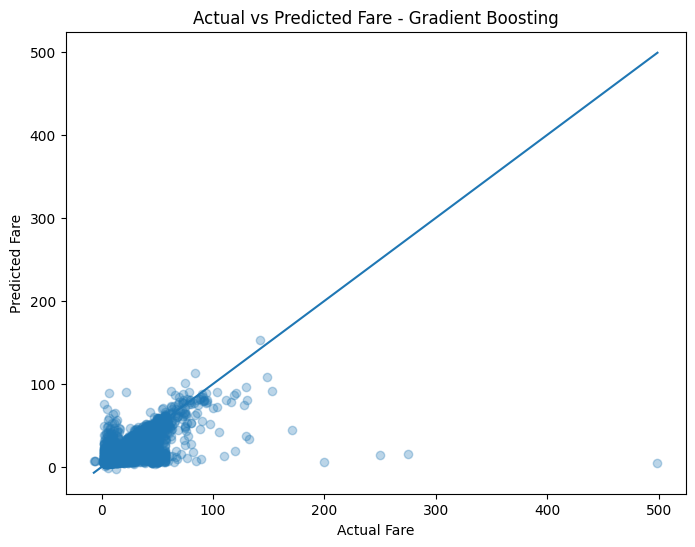

In [32]:
# Actual vs Predicted

plt.figure(figsize=(8, 6))

plt.scatter(ytest, ytest_pred_gb, alpha=0.3)

plt.xlabel("Actual Fare")
plt.ylabel("Predicted Fare")
plt.title("Actual vs Predicted Fare - Gradient Boosting")

plt.plot(
    [ytest.min(), ytest.max()],
    [ytest.min(), ytest.max()]
)

plt.show()

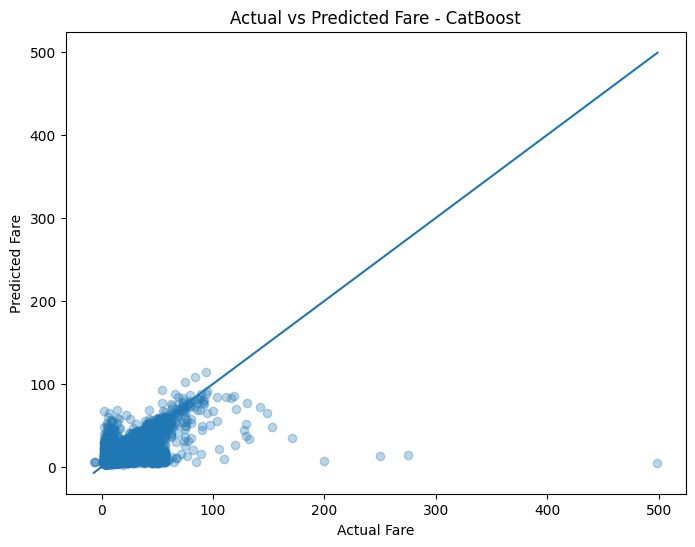

In [33]:
plt.figure(figsize=(8, 6))

plt.scatter(ytest, ytest_pred_cat, alpha=0.3)

plt.xlabel("Actual Fare")
plt.ylabel("Predicted Fare")
plt.title("Actual vs Predicted Fare - CatBoost")

plt.plot(
    [ytest.min(), ytest.max()],
    [ytest.min(), ytest.max()]
)

plt.show()

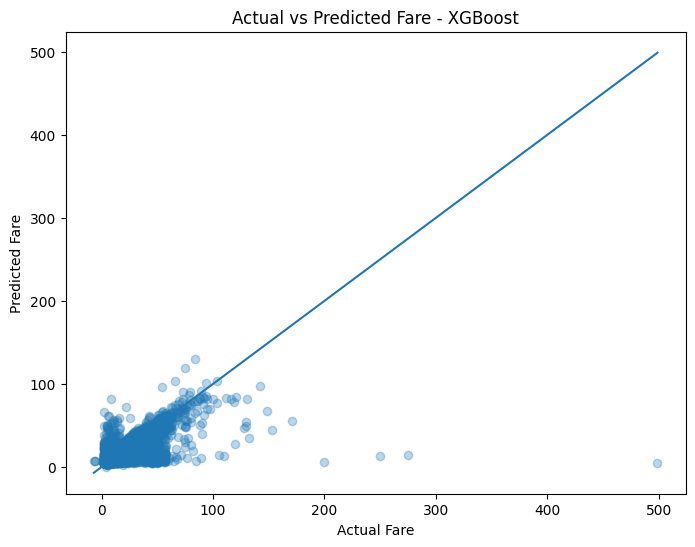

In [34]:
plt.figure(figsize=(8, 6))

plt.scatter(ytest, ytest_pred_xgb, alpha=0.3)

plt.xlabel("Actual Fare")
plt.ylabel("Predicted Fare")
plt.title("Actual vs Predicted Fare - XGBoost")

plt.plot(
    [ytest.min(), ytest.max()],
    [ytest.min(), ytest.max()]
)

plt.show()

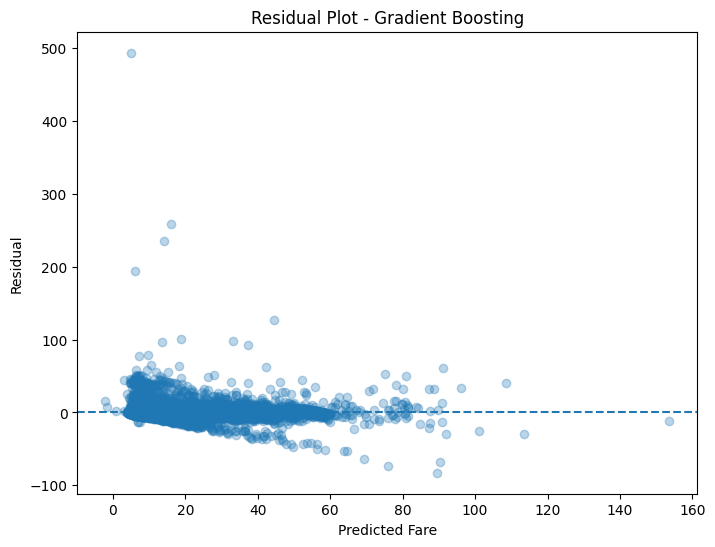

In [35]:
# Residual Analysis - Gradient Boosting

residual_gb = ytest - ytest_pred_gb

plt.figure(figsize=(8, 6))

plt.scatter(ytest_pred_gb, residual_gb, alpha=0.3)

plt.axhline(y=0, linestyle='--')

plt.xlabel("Predicted Fare")
plt.ylabel("Residual")
plt.title("Residual Plot - Gradient Boosting")

plt.show()

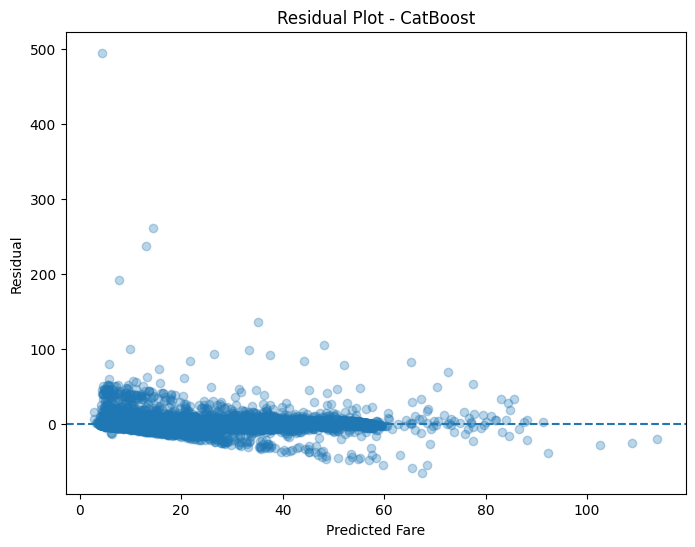

In [36]:
# Residual Analysis - CatBoost

residual_cat = ytest - ytest_pred_cat

plt.figure(figsize=(8, 6))

plt.scatter(ytest_pred_cat, residual_cat, alpha=0.3)

plt.axhline(y=0, linestyle='--')

plt.xlabel("Predicted Fare")
plt.ylabel("Residual")
plt.title("Residual Plot - CatBoost")

plt.show()

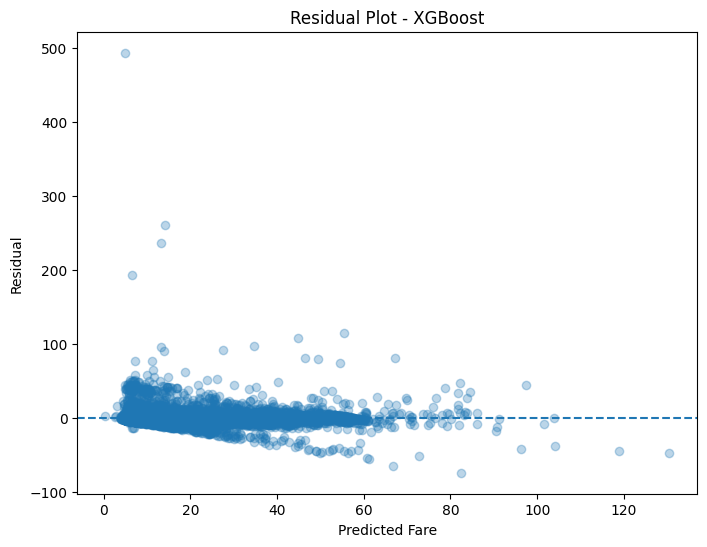

In [37]:
# Residual Analysis - XGBoost

residual_xgb = ytest - ytest_pred_xgb

plt.figure(figsize=(8, 6))

plt.scatter(ytest_pred_xgb, residual_xgb, alpha=0.3)

plt.axhline(y=0, linestyle='--')

plt.xlabel("Predicted Fare")
plt.ylabel("Residual")
plt.title("Residual Plot - XGBoost")

plt.show()

# Feature Importance

Gradient Boosting

In [40]:
# Feature Importance - Gradient Boosting

feature_importance_gb = pd.DataFrame({
    "Feature": x.columns,
    "Importance": model_gb.feature_importances_
})

feature_importance_gb = feature_importance_gb.sort_values(
    by="Importance",
    ascending=False
)

feature_importance_gb




,Feature,Importance
2,dropoff_longitude,0.465028
0,pickup_longitude,0.264226
3,dropoff_latitude,0.122968
1,pickup_latitude,0.106014
8,year,0.028703
5,hour,0.005167
6,day,0.002743
7,month,0.002187
9,dayofweek,0.001731
4,passenger_count,0.001233


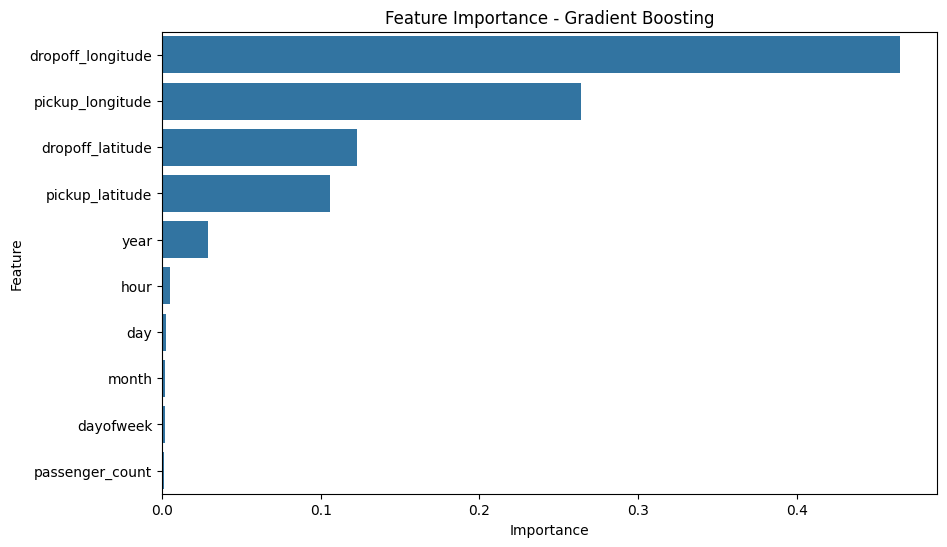

In [41]:
plt.figure(figsize=(10, 6))

sns.barplot(
    data=feature_importance_gb,
    x="Importance",
    y="Feature"
)

plt.title("Feature Importance - Gradient Boosting")

plt.show()

CatBoost

In [42]:
# Feature Importance - CatBoost

feature_importance_cat = pd.DataFrame({
    "Feature": x.columns,
    "Importance": model_cat.feature_importances_
})

feature_importance_cat = feature_importance_cat.sort_values(
    by="Importance",
    ascending=False
)

feature_importance_cat

,Feature,Importance
2,dropoff_longitude,29.868735
0,pickup_longitude,28.871964
3,dropoff_latitude,18.250903
1,pickup_latitude,14.023641
8,year,4.009356
5,hour,1.836147
7,month,0.976879
9,dayofweek,0.911091
6,day,0.854329
4,passenger_count,0.396954


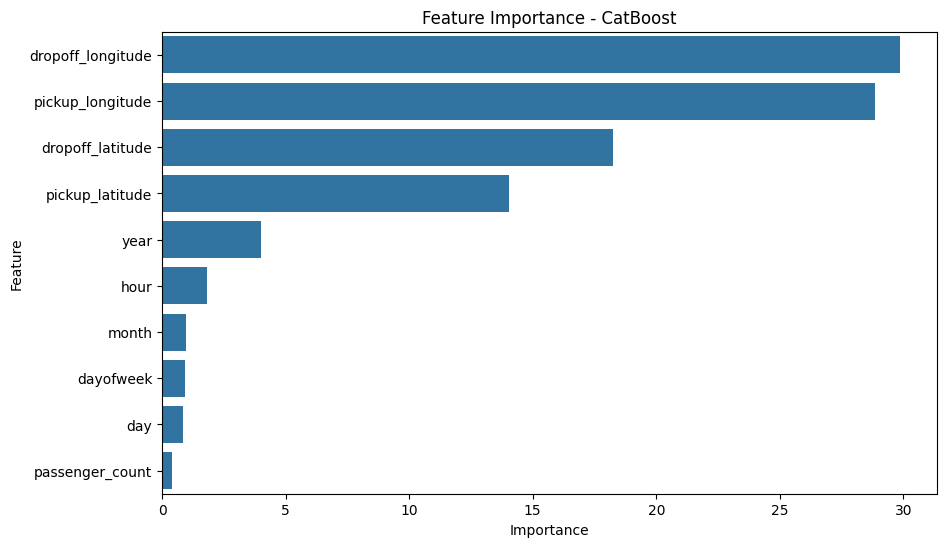

In [43]:
plt.figure(figsize=(10, 6))

sns.barplot(
    data=feature_importance_cat,
    x="Importance",
    y="Feature"
)

plt.title("Feature Importance - CatBoost")

plt.show()

XGBoost

In [44]:
# Feature Importance - XGBoost

feature_importance_xgb = pd.DataFrame({
    "Feature": x.columns,
    "Importance": model_xgb.feature_importances_
})

feature_importance_xgb = feature_importance_xgb.sort_values(
    by="Importance",
    ascending=False
)

feature_importance_xgb

,Feature,Importance
2,dropoff_longitude,0.376316
0,pickup_longitude,0.252096
1,pickup_latitude,0.103921
3,dropoff_latitude,0.097784
8,year,0.083697
6,day,0.021367
4,passenger_count,0.017450
7,month,0.016739
5,hour,0.015570
9,dayofweek,0.015060


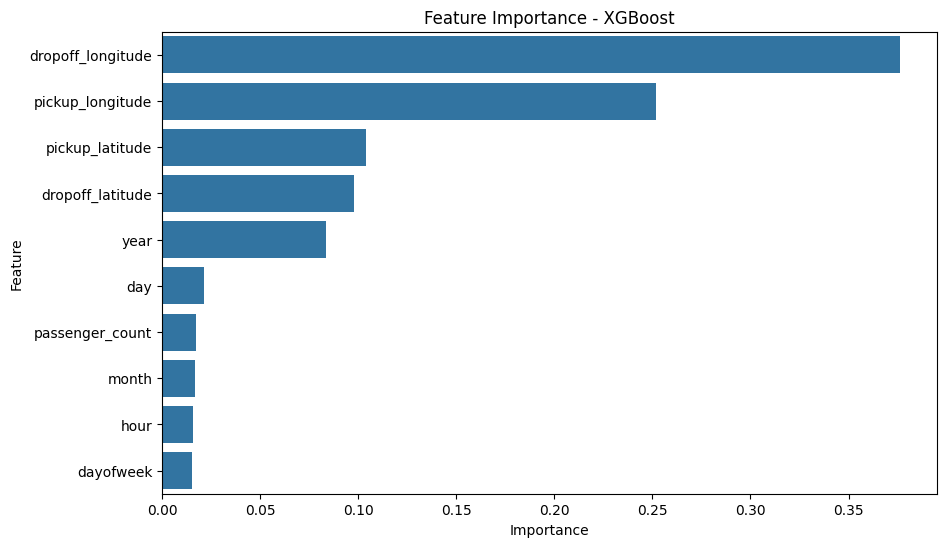

In [45]:
plt.figure(figsize=(10, 6))

sns.barplot(
    data=feature_importance_xgb,
    x="Importance",
    y="Feature"
)

plt.title("Feature Importance - XGBoost")

plt.show()

# SHAP

In [47]:
# SHAP Analysis - CatBoost

sample_x = xtest.sample(3000, random_state=42)

explainer = shap.TreeExplainer(model_cat)

shap_values = explainer.shap_values(sample_x)

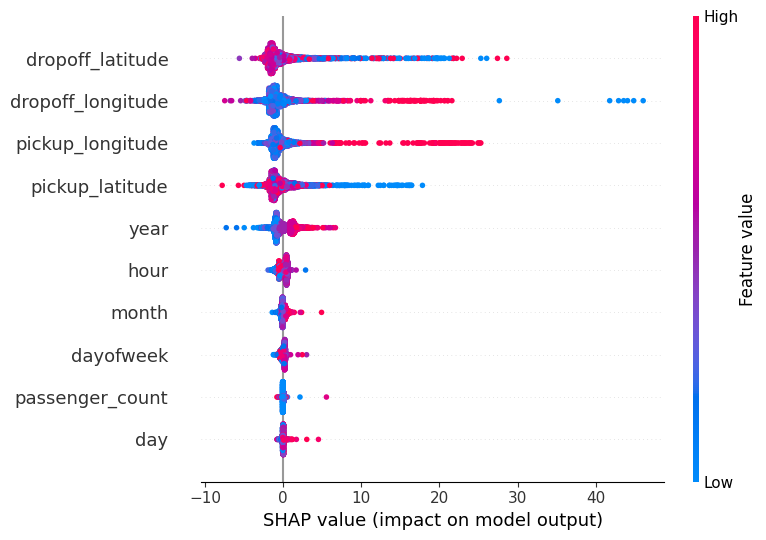

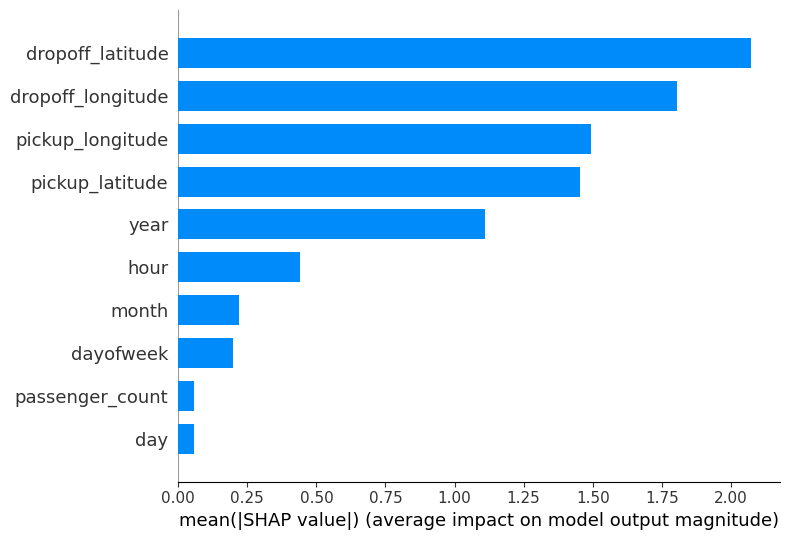

In [52]:
shap.summary_plot(shap_values,sample_x)
shap.summary_plot(shap_values,sample_x,plot_type="bar")


## Finding Best Model 

##  Best Model Based on Test R²

The models are ranked based on their Test R² score.

- **1st: Gradient Boosting — 72.07%**
- **2nd: CatBoost — 72.01%**
- **3rd: XGBoost — 71.45%**

### Conclusion

**Gradient Boosting** achieved the highest Test R² score of **72.07%**, making it the best-performing model based on R².

In [58]:
comparison_df.sort_values(by="Test R2",ascending=False)

,Model,Train Score (%),Test Score (%),Train R2,Test R2,Train RMSE,Test RMSE,Train MAE,Test MAE,Train MSE,Test MSE
5,Gradient Boosting,84.101774,72.073771,0.841018,0.720738,3.906195,5.448986,2.053597,2.233679,15.258361,29.691451
3,CatBoost,85.579014,72.006109,0.855790,0.720061,3.720292,5.455583,1.837128,2.035976,13.840576,29.763390
6,XGBoost,82.546423,71.447530,0.825464,0.714475,4.092812,5.509744,2.082441,2.233907,16.751113,30.357276
1,Random Forest,72.737757,63.846731,0.727378,0.638467,5.115174,6.199881,3.290588,3.420384,26.165003,38.438522
0,Decision Tree,74.785407,62.910879,0.747854,0.629109,4.919326,6.279612,3.122616,3.298060,24.199767,39.433530
4,Extra Trees,64.855695,44.968447,0.648557,0.449684,5.807739,7.649190,3.884030,4.500170,33.729831,58.510106
2,AdaBoost,46.131673,41.100803,0.461317,0.411008,7.190289,7.913421,4.997267,5.079333,51.700257,62.622224


##  Best Model Based on Test RMSE

The models are ranked based on their Test RMSE, where a **lower value indicates better performance**.

- **1st: Gradient Boosting — 5.45**
- **2nd: CatBoost — 5.46**
- **3rd: XGBoost — 5.51**

### Conclusion

**Gradient Boosting** achieved the lowest Test RMSE of **5.45**, indicating the best prediction accuracy based on RMSE.

In [59]:
comparison_df.sort_values(by="Test RMSE",ascending=True)

,Model,Train Score (%),Test Score (%),Train R2,Test R2,Train RMSE,Test RMSE,Train MAE,Test MAE,Train MSE,Test MSE
5,Gradient Boosting,84.101774,72.073771,0.841018,0.720738,3.906195,5.448986,2.053597,2.233679,15.258361,29.691451
3,CatBoost,85.579014,72.006109,0.855790,0.720061,3.720292,5.455583,1.837128,2.035976,13.840576,29.763390
6,XGBoost,82.546423,71.447530,0.825464,0.714475,4.092812,5.509744,2.082441,2.233907,16.751113,30.357276
1,Random Forest,72.737757,63.846731,0.727378,0.638467,5.115174,6.199881,3.290588,3.420384,26.165003,38.438522
0,Decision Tree,74.785407,62.910879,0.747854,0.629109,4.919326,6.279612,3.122616,3.298060,24.199767,39.433530
4,Extra Trees,64.855695,44.968447,0.648557,0.449684,5.807739,7.649190,3.884030,4.500170,33.729831,58.510106
2,AdaBoost,46.131673,41.100803,0.461317,0.411008,7.190289,7.913421,4.997267,5.079333,51.700257,62.622224


##  Best Model Based on Test MAE

The models are ranked based on their Test MAE, where a **lower value indicates better performance**.

- **1st: CatBoost — 2.04**
- **2nd: Gradient Boosting — 2.05**
- **3rd: XGBoost — 2.08**

### Conclusion

**CatBoost** achieved the lowest Test MAE of **2.04**, indicating the lowest average absolute prediction error.

In [60]:
comparison_df.sort_values(by="Test MAE",ascending=True)

,Model,Train Score (%),Test Score (%),Train R2,Test R2,Train RMSE,Test RMSE,Train MAE,Test MAE,Train MSE,Test MSE
3,CatBoost,85.579014,72.006109,0.855790,0.720061,3.720292,5.455583,1.837128,2.035976,13.840576,29.763390
5,Gradient Boosting,84.101774,72.073771,0.841018,0.720738,3.906195,5.448986,2.053597,2.233679,15.258361,29.691451
6,XGBoost,82.546423,71.447530,0.825464,0.714475,4.092812,5.509744,2.082441,2.233907,16.751113,30.357276
0,Decision Tree,74.785407,62.910879,0.747854,0.629109,4.919326,6.279612,3.122616,3.298060,24.199767,39.433530
1,Random Forest,72.737757,63.846731,0.727378,0.638467,5.115174,6.199881,3.290588,3.420384,26.165003,38.438522
4,Extra Trees,64.855695,44.968447,0.648557,0.449684,5.807739,7.649190,3.884030,4.500170,33.729831,58.510106
2,AdaBoost,46.131673,41.100803,0.461317,0.411008,7.190289,7.913421,4.997267,5.079333,51.700257,62.622224


##  Final Model Selection

Based on the overall comparison:

- **Gradient Boosting** performed best in Test R² and Test RMSE.
- **CatBoost** performed best in Test MAE.
- **XGBoost** also showed strong and competitive performance.

Therefore, **Gradient Boosting and CatBoost are selected as the top two candidate models for further analysis and final model selection.**

## Save Final model

In [61]:
final_model = model_cat

## Save Final Model using Pickel 

In [62]:
with open("final_model.pkl", "wb") as file:
    pickle.dump(final_model, file)

print("Final model saved successfully!")

Final model saved successfully!
